In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
import datetime
from keras.datasets import fashion_mnist
import wandb
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
%load_ext autoreload
%autoreload 2
from Model import NeuralNetwork

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
def normalize(x):
    return x.reshape(len(x), -1).astype('float64') / (np.max(x) - np.min(x))

In [24]:
def load_and_prepare_data(dataset="fashion_mnist"):
    # Load the Fashion MNIST dataset
    (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
    
    # Using train_test_split to separate validation data (10% of training data)
    x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=69)
    
    # Normalize image pixel values
    x_train = normalize(x_train)
    x_val   = normalize(x_val)
    x_test  = normalize(x_test)
    
    # Determine the number of classes from the unique labels
    classes = np.unique(y_train)
    num_classes = len(classes)
    
    # One-hot encode labels based on the discovered number of classes
    y_train = np.eye(num_classes)[y_train]
    y_val   = np.eye(num_classes)[y_val]
    y_test  = np.eye(num_classes)[y_test]
    
    return x_train, y_train, x_val, y_val, x_test, y_test

In [25]:
# Initialize WandB API
api = wandb.Api()

# Fetch all runs from the project
project = "fashion-mnist-classification"
runs = api.runs(project)

best_test_accuracy = -1
best_config = None

for run in runs:
    if run.state == "finished" and 'test_accuracy' in run.summary:
        current_acc = run.summary['test_accuracy']
        if current_acc > best_test_accuracy:
            best_test_accuracy = current_acc
            best_config = run.config

if best_config:
    print(f"Best Test Accuracy: {best_test_accuracy:.4f}")
    print("Best Configuration:", dict(best_config))  # Convert to standard dict
else:
    print("No completed runs found.")

Best Test Accuracy: 0.8766
Best Configuration: {'loss': 'cross_entropy', 'epochs': 10, 'optimizer': 'momentum', 'activation': 'Tanh', 'batch_size': 64, 'num_layers': 4, 'hidden_size': 128, 'weight_init': 'Xavier', 'weight_decay': 0.0005, 'learning_rate': 0.0001}


In [26]:
x_train, y_train, x_val, y_val, x_test, y_test = load_and_prepare_data()

# Rebuild the best model with FIXED dictionary access
model = NeuralNetwork(
    input_size=x_train.shape[1],
    num_classes=y_train.shape[1],
    num_hidden=best_config['num_layers'],
    hidden_units=best_config['hidden_size'],
    init_method=best_config['weight_init'],
    activation=best_config['activation'],
    loss_fn=best_config['loss'],
    epochs=best_config['epochs'],
    batch_size=best_config['batch_size'],
    optimizer=best_config['optimizer'],
    lr=best_config['learning_rate'],
    weight_decay=best_config.get('weight_decay', 0),
    momentum=best_config.get('momentum', 0.9),
    beta=best_config.get('beta', 0.9),
    beta1=best_config.get('beta1', 0.9),
    beta2=best_config.get('beta2', 0.999),
    epsilon=best_config.get('epsilon', 1e-6)
)

# Retrain and predict
model.fit(x_train, y_train, x_val, y_val)
test_preds = model.predict(x_test.T)

Epoch 1: train_loss = 0.43, valid_loss = 0.45, train_accuracy = 0.85, val_accuracy = 0.84
Epoch 2: train_loss = 0.37, valid_loss = 0.40, train_accuracy = 0.86, val_accuracy = 0.86
Epoch 3: train_loss = 0.35, valid_loss = 0.38, train_accuracy = 0.87, val_accuracy = 0.87
Epoch 4: train_loss = 0.33, valid_loss = 0.37, train_accuracy = 0.88, val_accuracy = 0.87
Epoch 5: train_loss = 0.31, valid_loss = 0.36, train_accuracy = 0.89, val_accuracy = 0.87
Epoch 6: train_loss = 0.30, valid_loss = 0.35, train_accuracy = 0.89, val_accuracy = 0.88
Epoch 7: train_loss = 0.29, valid_loss = 0.35, train_accuracy = 0.89, val_accuracy = 0.88
Epoch 8: train_loss = 0.28, valid_loss = 0.34, train_accuracy = 0.90, val_accuracy = 0.88
Epoch 9: train_loss = 0.28, valid_loss = 0.34, train_accuracy = 0.90, val_accuracy = 0.88
Epoch 10: train_loss = 0.27, valid_loss = 0.34, train_accuracy = 0.90, val_accuracy = 0.88


In [27]:
# After predictions
print("x_test.T shape:", test_preds.shape)  # Should be (784, 10000)
print("test_preds shape:", y_test.shape)  # Should be (10, 10000)

x_test.T shape: (10000, 10)
test_preds shape: (10000, 10)


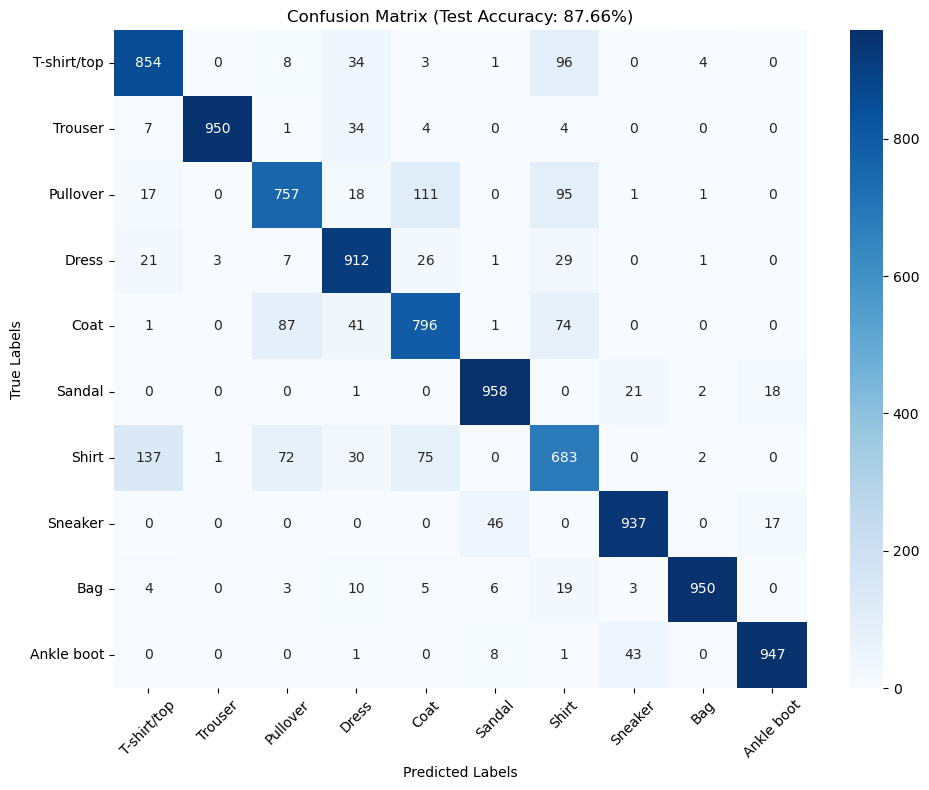

In [30]:
# Get class names for Fashion MNIST
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Generate confusion matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(test_preds, axis=1))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix (Test Accuracy: {best_test_accuracy:.2%})')
plt.tight_layout()
plt.show()